In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

Dataset:
   X  Y  Z Class
0  1  1  1     I
1  1  1  0     I
2  0  0  1    II
3  1  0  0    II

Information Gain
X = 0.0
Y = 1.0
Z = 0.0

Actual Classes : 
['I', 'I', 'II', 'II']

Prediction Classes : 
['I', 'I', 'II', 'II']


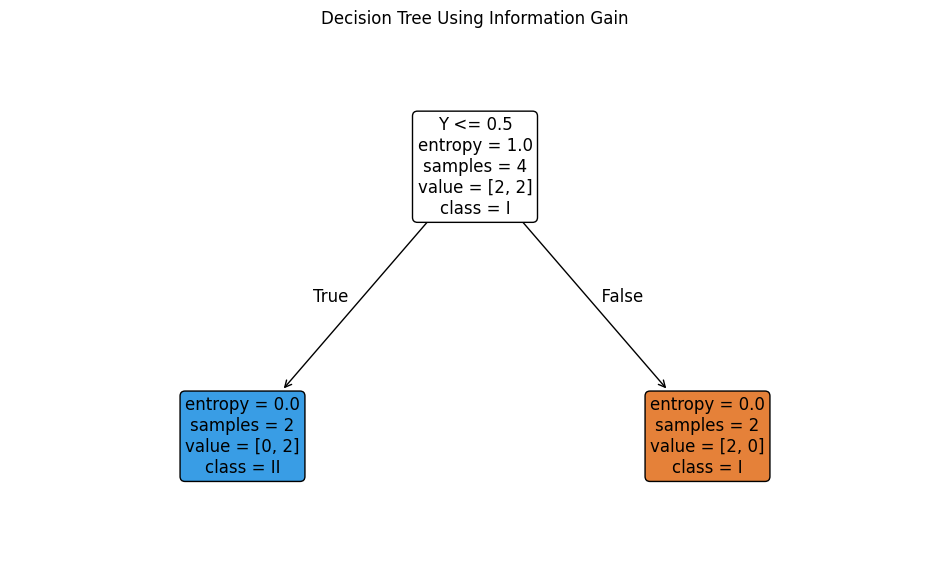

In [7]:
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.tree import DecisionTreeClassifier,plot_tree


# --------------------------------------------
# CREATE DATASET
# --------------------------------------------

data = {
    'X' :[1,1,0,1],
    'Y' :[1,1,0,0],
    'Z' :[1,0,1,0],
    'Class' : ['I','I','II','II']
}

df = pd.DataFrame(data)

print("Dataset:")
print(df)

# ---------------------------------------
# 2.Separete Features and Target
# ----------------------------------------

X = df[['X','Y','Z']]
y = df['Class']


# ----------------------------------------
# 3.Creater devision Tree
# ----------------------------------------


model = DecisionTreeClassifier(
    criterion = 'entropy',
    random_state = 42
)


# ---------------------------------------
# Train the Model
# ---------------------------------------


model.fit(X,y)

# ------------------------------------------
# 4.Display Information Gain
# ------------------------------------------

print("\nInformation Gain")

for feature,importance in zip(X.columns, model.feature_importances_):
    print(feature,"=",round(importance,4))


# -------------------------------------------------
# 5.PREDICTIONS
# --------------------------------------------------

y_pred = model.predict(X)

print("\nActual Classes : ")

print(list(y))


print("\nPrediction Classes : ")

print(list(y_pred))


# ----------------------------------------
# 6.VISUALIZATION DECISION TREE
# ----------------------------------------

plt.figure(figsize=(12,7))

plot_tree(
    model,
    feature_names = X.columns,
    class_names = model.classes_,
    filled = True,
    rounded = True,
    fontsize = 12
)

plt.title("Decision Tree Using Information Gain")

plt.show()

IRIS DATASET
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

Dataset Shape:
(150, 6)

Columns Names:
Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm

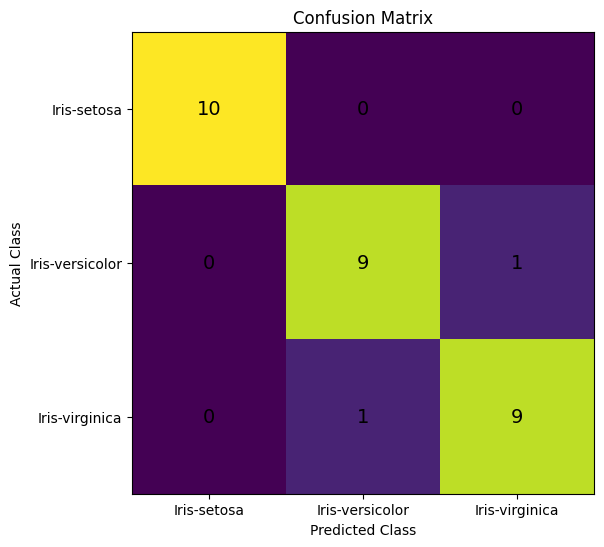

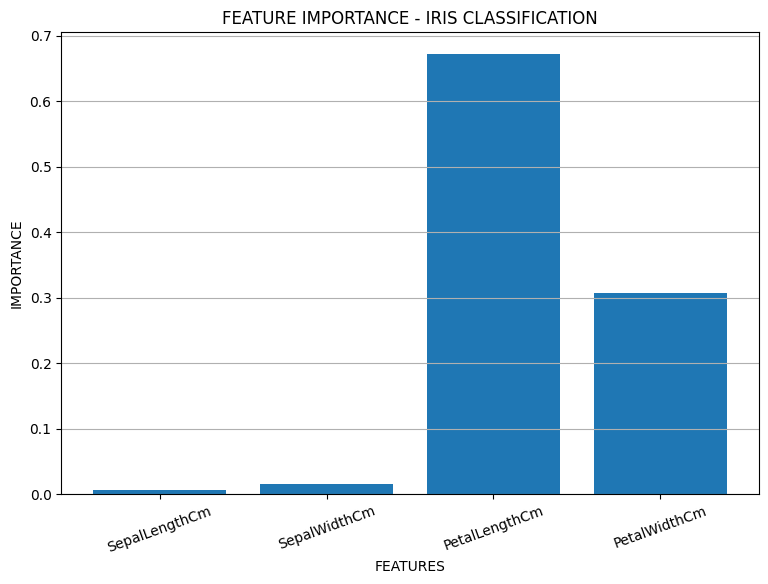

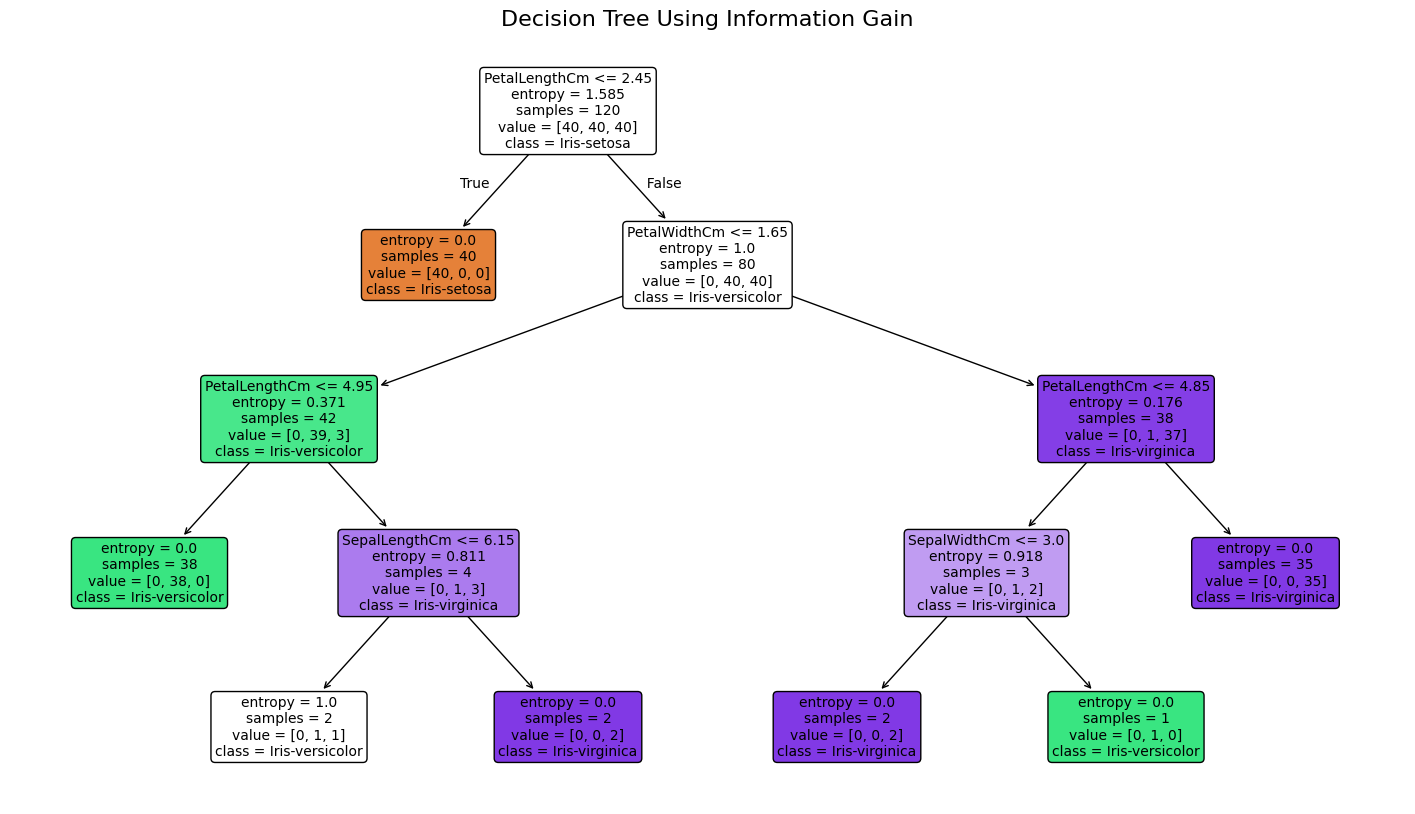

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree

from sklearn.metrics import(
    accuracy_score,
    confusion_matrix,
    classification_report
)

# -----------------------------------------
# LOAD KAGGLE DATASET
# -----------------------------------------

path = "/kaggle/input/datasets/uciml/iris/Iris.csv"

df = pd.read_csv(path)

print("="*60)

print("IRIS DATASET")
print("="*60)

print(df.head())


print("\nDataset Shape:")
print(df.shape)


print("\nColumns Names:")
print(df.columns)


print("\nDataset Information:")
print(df.info())

print("\nStatistical Description:")
print(df.describe())


print("\nClass Distribution: ")
print(df["Species"].value_counts())



# ------------------------------------
# 4.REMOVE ID COLUMN
# -------------------------------------


X =df[
    [
        "SepalLengthCm",
        "SepalWidthCm",
        "PetalLengthCm",
        "PetalWidthCm"
    ]
]

y = df["Species"]

# -------------------------------------
# 5.Split Dataset into training and Testing
# -------------------------------------


X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size = 0.20,
    random_state = 42,
    stratify = y
    
)

print("\nTraining Samples:",X_train.shape[0])
print("Testing Samples :",X_test.shape[0])

# -------------------------------------
# 6.CREATE DECISION TREE
# -------------------------------------


model = DecisionTreeClassifier(
    criterion = 'entropy',
    max_depth =4,
    random_state=42
)

# -------------------------------------
# 7.TRAIN THE MODEL
# -------------------------------------
model.fit(X_train,y_train)
print("\nDecision Tree Training Completed!")

# -------------------------------------
# 8.MAKE PREDICTIONS
# -------------------------------------


y_pred = model.predict(X_test)


print("\nActual Values:")
print(y_test.values)

print("\nPredicted Values:")
print(y_pred)

accuracy = accuracy_score(y_test,y_pred)


print("\n"+"="*60)
print("Model Accuracy")
print("="*60)

print("Accuracy = ",round(accuracy*100,2),"%")

 # ----------------------------------------
# 10.Classification Report
 # ----------------------------------------

print("\nClassification Report: ")
print(
    classification_report(
        y_test,
        y_pred
    )
)

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix: ")
print(cm)

plt.figure(figsize=(7,6))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    [0,1,2],
    model.classes_
)

plt.yticks(
    [0,1,2],
    model.classes_
)


# Display Values
for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(
            j,
            i,
            cm[i,j],
            ha="center",
            va="center",
            fontsize = 14
        )

print("\n"+"="*60)
print("FEATURE IMPORTANCE")
print("="*60)

for feature,importance in zip(
    X.columns,
    model.feature_importances_
):
    print(
        feature,
        "=",
        round(importance,4)
    )

# 14.FEATURE IMNPORTNT VISUALIZATION
plt.figure(figsize=(9,6))

plt.bar(
    X.columns,
    model.feature_importances_
)

plt.xlabel("FEATURES")
plt.ylabel("IMPORTANCE")

plt.title(
    "FEATURE IMPORTANCE - IRIS CLASSIFICATION"
)

plt.xticks(rotation=20)

plt.grid(axis='y')

plt.show()

# ----------------------------------------
# 6.VISUALIZATION DECISION TREE
# ----------------------------------------

plt.figure(figsize=(18,10))

plot_tree(
    model,
    feature_names = X.columns,
    class_names = model.classes_,
    filled = True,
    rounded = True,
    fontsize = 10
)

plt.title("Decision Tree Using Information Gain",fontsize = 16)

plt.show()